# VoxIntel — 08: Error Propagation Analysis

## Goal

This notebook is the **central controlled experiment** of VoxIntel.

Notebook 07 trained the intent classifier on **ground-truth transcripts only** and
saved the best DistilBERT model. Here we reuse that same frozen classifier and run
it on **three transcript sources**:

1. `ground_truth`
2. `baseline_transcript`
3. `finetuned_transcript`

Only the transcript source changes. The classifier, tokenizer, label mapping, and
metrics remain fixed.

This lets us answer the core research question:

> **How do ASR transcription errors affect downstream intent understanding?**


## Cell 0 — Make sure `src` is importable


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Cell 1 — Imports


In [2]:
import json
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, DistilBertForSequenceClassification

from src.utils.text import clean_transcript

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

c:\Users\ACER\anaconda3\envs\torch26\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2 — Config


In [3]:
MASTER_TRANSCRIPTS_PATH = PROJECT_ROOT / "reports" / "master_transcripts.csv"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / "distilbert_intent"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = PROJECT_ROOT / "reports"

MODEL_NAME = str(MODEL_OUTPUT_DIR)
MAX_LENGTH = 64
BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Using device:", DEVICE)
print("MASTER_TRANSCRIPTS_PATH:", MASTER_TRANSCRIPTS_PATH)
print("MODEL_OUTPUT_DIR:", MODEL_OUTPUT_DIR)

Using device: cuda
MASTER_TRANSCRIPTS_PATH: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\master_transcripts.csv
MODEL_OUTPUT_DIR: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\distilbert_intent


## Cell 3 — Load master transcript dataset


In [4]:
if not MASTER_TRANSCRIPTS_PATH.exists():
    raise FileNotFoundError(
        f"master_transcripts.csv not found at {MASTER_TRANSCRIPTS_PATH}. "
        "Run Notebook 06 first or adjust MASTER_TRANSCRIPTS_PATH."
    )

master_df = pd.read_csv(MASTER_TRANSCRIPTS_PATH)
print(master_df.shape)
print(master_df.columns.tolist())
display(master_df.head())


(8690, 8)
['audio_path', 'ground_truth', 'baseline_transcript', 'finetuned_transcript', 'intent', 'scenario', 'confidence', 'latency_ms']


,audio_path,ground_truth,baseline_transcript,finetuned_transcript,intent,scenario,confidence,latency_ms
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,qa,0.966625,27.5224
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,qa,0.944935,27.0343
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.988258,29.6696
3,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.981073,28.2033
4,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.990505,33.0819


## Cell 4 — Validate required columns


In [5]:
required_columns = [
    "intent",
    "scenario",
    "ground_truth",
    "baseline_transcript",
    "finetuned_transcript",
]

missing_columns = [c for c in required_columns if c not in master_df.columns]
if missing_columns:
    raise ValueError(f"master_transcripts.csv is missing required columns: {missing_columns}")

print("All required columns are present.")


All required columns are present.


## Cell 5 — Load tokenizer, model, and label mappings from Notebook 07


In [6]:
label2id_path = ARTIFACTS_DIR / "label2id.json"
id2label_path = ARTIFACTS_DIR / "id2label.json"

if not label2id_path.exists() or not id2label_path.exists():
    raise FileNotFoundError(
        "label2id.json and/or id2label.json not found in artifacts/. Run Notebook 07 first."
    )

with open(label2id_path, "r", encoding="utf-8") as f:
    label2id = json.load(f)
with open(id2label_path, "r", encoding="utf-8") as f:
    id2label = {int(k): v for k, v in json.load(f).items()}

if not MODEL_OUTPUT_DIR.exists():
    raise FileNotFoundError(
        f"Saved classifier not found at {MODEL_OUTPUT_DIR}. Run Notebook 07 first."
    )

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(DEVICE)
model.eval()

print(f"Loaded classifier with {len(label2id)} labels")


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 413.11it/s, Materializing param=pre_classifier.weight]                                  


Loaded classifier with 91 labels


## Cell 6 — Keep only rows whose intent is known to the Notebook 07 classifier


In [7]:
results_df = master_df.copy()
results_df["label"] = results_df["intent"].map(label2id)

n_unseen = results_df["label"].isna().sum()
if n_unseen:
    print(f"Dropping {n_unseen} rows with intents unseen in Notebook 07 training")
    results_df = results_df.dropna(subset=["label"]).copy()

results_df["label"] = results_df["label"].astype(int)
results_df = results_df.reset_index(drop=True)

print(results_df.shape)
display(results_df[["intent", "scenario", "label"]].head())


Dropping 2 rows with intents unseen in Notebook 07 training
(8688, 9)


,intent,scenario,label
0,qa_currency,qa,61
1,qa_currency,qa,61
2,email_query,email,22
3,email_query,email,22
4,email_query,email,22


## Cell 7 — Clean transcripts consistently


In [8]:
TRANSCRIPT_COLUMNS = {
    "ground_truth": "ground_truth",
    "baseline": "baseline_transcript",
    "finetuned": "finetuned_transcript",
}

for source_name, column_name in TRANSCRIPT_COLUMNS.items():
    clean_column = f"clean_{source_name}_transcript"
    results_df[clean_column] = (
        results_df[column_name]
        .fillna("")
        .astype(str)
        .apply(clean_transcript)
    )

display(results_df[[
    "ground_truth", "clean_ground_truth_transcript",
    "baseline_transcript", "clean_baseline_transcript",
    "finetuned_transcript", "clean_finetuned_transcript",
]].head())


,ground_truth,clean_ground_truth_transcript,baseline_transcript,clean_baseline_transcript,finetuned_transcript,clean_finetuned_transcript
0,siri what is one american dollar in japanese yen,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN
1,siri what is one american dollar in japanese yen,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN
2,how many unread emails do i have,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE
3,how many unread emails do i have,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE
4,how many unread emails do i have,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE


## Cell 8 — Sanity-check empty transcripts


In [9]:
for source_name in TRANSCRIPT_COLUMNS:
    clean_column = f"clean_{source_name}_transcript"
    n_empty = (results_df[clean_column].str.len() == 0).sum()
    print(f"{source_name:12s} empty transcripts: {n_empty}")


ground_truth empty transcripts: 0
baseline     empty transcripts: 2
finetuned    empty transcripts: 1


## Cell 9 — Intent prediction helper


In [10]:
def predict_intents(texts, tokenizer, model, batch_size=BATCH_SIZE, max_length=MAX_LENGTH, device=DEVICE):
    all_logits = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        encoded = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            logits = outputs.logits.detach().cpu()
        all_logits.append(logits)

    logits = torch.cat(all_logits, dim=0)
    probs = torch.softmax(logits, dim=-1).numpy()
    pred_labels = probs.argmax(axis=1)
    confidences = probs[np.arange(len(probs)), pred_labels]
    top3_indices = np.argsort(-probs, axis=1)[:, :3]

    return pred_labels, probs, confidences, top3_indices


## Cell 10 — Evaluation helper for one transcript source


In [11]:
def evaluate_transcript_source(source_name, clean_column, results_df, tokenizer, model):
    source_df = results_df.copy()
    texts = source_df[clean_column].fillna("").astype(str).tolist()

    pred_labels, probs, confidences, top3_indices = predict_intents(
        texts=texts,
        tokenizer=tokenizer,
        model=model,
    )

    source_df["predicted_label"] = pred_labels
    source_df["predicted_intent"] = source_df["predicted_label"].map(id2label)
    source_df["correct"] = source_df["label"] == source_df["predicted_label"]
    source_df["confidence"] = confidences
    source_df["top3_intents"] = [[id2label[i] for i in row] for row in top3_indices]
    source_df["top3_correct"] = [
        true_intent in top3 for true_intent, top3 in zip(source_df["intent"], source_df["top3_intents"])
    ]
    source_df["transcript_source"] = source_name
    source_df["input_transcript"] = source_df[clean_column]

    accuracy = accuracy_score(source_df["label"], source_df["predicted_label"])
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        source_df["label"], source_df["predicted_label"], average="macro", zero_division=0
    )
    top3_accuracy = source_df["top3_correct"].mean()

    metrics_row = {
        "transcript_source": source_name,
        "n_samples": len(source_df),
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "macro_f1": f1_macro,
        "top3_accuracy": top3_accuracy,
        "mean_confidence": source_df["confidence"].mean(),
        "median_confidence": source_df["confidence"].median(),
    }

    return source_df, probs, metrics_row


## Cell 11 — Run the frozen classifier on all three transcript sources


In [12]:
ground_truth_df, ground_truth_probs, ground_truth_metrics = evaluate_transcript_source(
    source_name="ground_truth",
    clean_column="clean_ground_truth_transcript",
    results_df=results_df,
    tokenizer=tokenizer,
    model=model,
)

baseline_df, baseline_probs, baseline_metrics = evaluate_transcript_source(
    source_name="baseline",
    clean_column="clean_baseline_transcript",
    results_df=results_df,
    tokenizer=tokenizer,
    model=model,
)

finetuned_df, finetuned_probs, finetuned_metrics = evaluate_transcript_source(
    source_name="finetuned",
    clean_column="clean_finetuned_transcript",
    results_df=results_df,
    tokenizer=tokenizer,
    model=model,
)

metric_comparison_df = pd.DataFrame([
    ground_truth_metrics,
    baseline_metrics,
    finetuned_metrics,
])

display(metric_comparison_df)

,transcript_source,n_samples,accuracy,precision_macro,recall_macro,macro_f1,top3_accuracy,mean_confidence,median_confidence
0,ground_truth,8688,0.857735,0.696729,0.715841,0.703180,0.944406,0.922548,0.980201
1,baseline,8688,0.384899,0.404243,0.283904,0.308180,0.515654,0.734901,0.837562
2,finetuned,8688,0.734346,0.572839,0.570868,0.555436,0.845419,0.861017,0.968617


## Cell 12 — Comparison table for the report


In [13]:
display_columns = [
    "transcript_source",
    "n_samples",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "macro_f1",
    "top3_accuracy",
    "mean_confidence",
    "median_confidence",
]

display(metric_comparison_df[display_columns].round(4))

,transcript_source,n_samples,accuracy,precision_macro,recall_macro,macro_f1,top3_accuracy,mean_confidence,median_confidence
0,ground_truth,8688,0.8577,0.6967,0.7158,0.7032,0.9444,0.9225,0.9802
1,baseline,8688,0.3849,0.4042,0.2839,0.3082,0.5157,0.7349,0.8376
2,finetuned,8688,0.7343,0.5728,0.5709,0.5554,0.8454,0.8610,0.9686


## Cell 13 — Add recovery/degradation summary against the upper bound


In [14]:
gt_acc = ground_truth_metrics["accuracy"]
gt_f1 = ground_truth_metrics["macro_f1"]

baseline_drop_acc = gt_acc - baseline_metrics["accuracy"]
finetuned_drop_acc = gt_acc - finetuned_metrics["accuracy"]
recovery_acc = finetuned_metrics["accuracy"] - baseline_metrics["accuracy"]

baseline_drop_f1 = gt_f1 - baseline_metrics["macro_f1"]
finetuned_drop_f1 = gt_f1 - finetuned_metrics["macro_f1"]
recovery_f1 = finetuned_metrics["macro_f1"] - baseline_metrics["macro_f1"]

error_propagation_summary_df = pd.DataFrame([
    {
        "metric": "accuracy",
        "ground_truth": gt_acc,
        "baseline": baseline_metrics["accuracy"],
        "finetuned": finetuned_metrics["accuracy"],
        "baseline_drop_from_upper_bound": baseline_drop_acc,
        "finetuned_drop_from_upper_bound": finetuned_drop_acc,
        "recovery_from_baseline": recovery_acc,
    },
    {
        "metric": "macro_f1",
        "ground_truth": gt_f1,
        "baseline": baseline_metrics["macro_f1"],
        "finetuned": finetuned_metrics["macro_f1"],
        "baseline_drop_from_upper_bound": baseline_drop_f1,
        "finetuned_drop_from_upper_bound": finetuned_drop_f1,
        "recovery_from_baseline": recovery_f1,
    },
])

display(error_propagation_summary_df.round(4))


,metric,ground_truth,baseline,finetuned,baseline_drop_from_upper_bound,finetuned_drop_from_upper_bound,recovery_from_baseline
0,accuracy,0.8577,0.3849,0.7343,0.4728,0.1234,0.3494
1,macro_f1,0.7032,0.3082,0.5554,0.3950,0.1477,0.2473


## Cell 14 — Per-intent F1 comparison


In [15]:
def build_per_group_f1(df, group_col):
    rows = []
    for key, group in df.groupby(group_col):
        y_true = group["label"]
        y_pred = group["predicted_label"]
        _, _, f1_macro, _ = precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
        rows.append({
            group_col: key,
            "n_samples": len(group),
            "f1": f1_macro,
        })
    return pd.DataFrame(rows).sort_values(["f1", "n_samples"], ascending=[False, False]).reset_index(drop=True)


ground_truth_intent_f1_df = build_per_group_f1(ground_truth_df, "intent").rename(columns={"f1": "ground_truth_f1", "n_samples": "n_samples_ground_truth"})
baseline_intent_f1_df = build_per_group_f1(baseline_df, "intent").rename(columns={"f1": "baseline_f1", "n_samples": "n_samples_baseline"})
finetuned_intent_f1_df = build_per_group_f1(finetuned_df, "intent").rename(columns={"f1": "finetuned_f1", "n_samples": "n_samples_finetuned"})

per_intent_f1_comparison_df = ground_truth_intent_f1_df[["intent", "ground_truth_f1", "n_samples_ground_truth"]]     .merge(baseline_intent_f1_df[["intent", "baseline_f1"]], on="intent", how="outer")     .merge(finetuned_intent_f1_df[["intent", "finetuned_f1"]], on="intent", how="outer")

per_intent_f1_comparison_df["baseline_drop"] = per_intent_f1_comparison_df["ground_truth_f1"] - per_intent_f1_comparison_df["baseline_f1"]
per_intent_f1_comparison_df["finetuned_drop"] = per_intent_f1_comparison_df["ground_truth_f1"] - per_intent_f1_comparison_df["finetuned_f1"]
per_intent_f1_comparison_df["recovery"] = per_intent_f1_comparison_df["finetuned_f1"] - per_intent_f1_comparison_df["baseline_f1"]

per_intent_f1_comparison_df = per_intent_f1_comparison_df.sort_values("baseline_drop", ascending=False).reset_index(drop=True)
display(per_intent_f1_comparison_df.head(20))


,intent,ground_truth_f1,n_samples_ground_truth,baseline_f1,finetuned_f1,baseline_drop,finetuned_drop,recovery
0,transport_taxi,1.000000,97,0.018145,0.136713,0.981855,0.863287,0.118568
1,audio_volume_down,1.000000,95,0.026357,0.104283,0.973643,0.895717,0.077926
2,qa_currency,1.000000,108,0.028947,0.085714,0.971053,0.914286,0.056767
3,transport_traffic,1.000000,87,0.032051,0.003457,0.967949,0.996543,-0.028594
4,transport_ticket,1.000000,101,0.036092,0.243655,0.963908,0.756345,0.207563
5,email_addcontact,1.000000,20,0.036364,0.473684,0.963636,0.526316,0.437321
6,iot_wemo_off,1.000000,26,0.042424,0.000000,0.957576,1.000000,-0.042424
7,iot_hue_lightup,1.000000,49,0.049145,1.000000,0.950855,0.000000,0.950855
8,music_settings,1.000000,22,0.052910,0.096552,0.947090,0.903448,0.043642
9,iot_coffee,1.000000,68,0.060748,0.064565,0.939252,0.935435,0.003817


## Cell 15 — Per-scenario F1 comparison


In [16]:
ground_truth_scenario_f1_df = build_per_group_f1(ground_truth_df, "scenario").rename(columns={"f1": "ground_truth_f1", "n_samples": "n_samples_ground_truth"})
baseline_scenario_f1_df = build_per_group_f1(baseline_df, "scenario").rename(columns={"f1": "baseline_f1", "n_samples": "n_samples_baseline"})
finetuned_scenario_f1_df = build_per_group_f1(finetuned_df, "scenario").rename(columns={"f1": "finetuned_f1", "n_samples": "n_samples_finetuned"})

per_scenario_f1_comparison_df = ground_truth_scenario_f1_df[["scenario", "ground_truth_f1", "n_samples_ground_truth"]]     .merge(baseline_scenario_f1_df[["scenario", "baseline_f1"]], on="scenario", how="outer")     .merge(finetuned_scenario_f1_df[["scenario", "finetuned_f1"]], on="scenario", how="outer")

per_scenario_f1_comparison_df["baseline_drop"] = per_scenario_f1_comparison_df["ground_truth_f1"] - per_scenario_f1_comparison_df["baseline_f1"]
per_scenario_f1_comparison_df["finetuned_drop"] = per_scenario_f1_comparison_df["ground_truth_f1"] - per_scenario_f1_comparison_df["finetuned_f1"]
per_scenario_f1_comparison_df["recovery"] = per_scenario_f1_comparison_df["finetuned_f1"] - per_scenario_f1_comparison_df["baseline_f1"]

per_scenario_f1_comparison_df = per_scenario_f1_comparison_df.sort_values("baseline_drop", ascending=False).reset_index(drop=True)
display(per_scenario_f1_comparison_df.head(20))


,scenario,ground_truth_f1,n_samples_ground_truth,baseline_f1,finetuned_f1,baseline_drop,finetuned_drop,recovery
0,transport,0.788809,431,0.056263,0.134981,0.732546,0.653828,0.078718
1,iot,0.602153,483,0.090254,0.139931,0.511899,0.462221,0.049677
2,takeaway,0.453865,186,0.041479,0.121011,0.412386,0.332854,0.079532
3,audio,0.404273,285,0.043093,0.151250,0.361180,0.253022,0.108158
4,datetime,0.392956,362,0.035242,0.101787,0.357714,0.291169,0.066546
5,music,0.381221,252,0.052580,0.110973,0.328642,0.270248,0.058394
6,alarm,0.345326,366,0.032538,0.120649,0.312788,0.224677,0.088111
7,email,0.325894,597,0.037397,0.178695,0.288497,0.147199,0.141298
8,social,0.264958,270,0.021606,0.048445,0.243352,0.216513,0.026839
9,lists,0.273294,440,0.033990,0.154584,0.239304,0.118710,0.120594


## Cell 16 — Confidence comparison


In [17]:
confidence_comparison_df = pd.DataFrame([
    {
        "transcript_source": "ground_truth",
        "mean_confidence": ground_truth_df["confidence"].mean(),
        "median_confidence": ground_truth_df["confidence"].median(),
        "std_confidence": ground_truth_df["confidence"].std(),
        "mean_confidence_correct": ground_truth_df.loc[ground_truth_df["correct"], "confidence"].mean(),
        "mean_confidence_incorrect": ground_truth_df.loc[~ground_truth_df["correct"], "confidence"].mean(),
    },
    {
        "transcript_source": "baseline",
        "mean_confidence": baseline_df["confidence"].mean(),
        "median_confidence": baseline_df["confidence"].median(),
        "std_confidence": baseline_df["confidence"].std(),
        "mean_confidence_correct": baseline_df.loc[baseline_df["correct"], "confidence"].mean(),
        "mean_confidence_incorrect": baseline_df.loc[~baseline_df["correct"], "confidence"].mean(),
    },
    {
        "transcript_source": "finetuned",
        "mean_confidence": finetuned_df["confidence"].mean(),
        "median_confidence": finetuned_df["confidence"].median(),
        "std_confidence": finetuned_df["confidence"].std(),
        "mean_confidence_correct": finetuned_df.loc[finetuned_df["correct"], "confidence"].mean(),
        "mean_confidence_incorrect": finetuned_df.loc[~finetuned_df["correct"], "confidence"].mean(),
    },
])

display(confidence_comparison_df.round(4))


,transcript_source,mean_confidence,median_confidence,std_confidence,mean_confidence_correct,mean_confidence_incorrect
0,ground_truth,0.9225,0.9802,0.1441,0.9514,0.7488
1,baseline,0.7349,0.8376,0.2615,0.8769,0.6461
2,finetuned,0.8610,0.9686,0.2050,0.9271,0.6783


## Cell 17 — Which intents and scenarios degrade most?


In [18]:
most_sensitive_intents_df = per_intent_f1_comparison_df.sort_values("baseline_drop", ascending=False).head(20)
most_recovered_intents_df = per_intent_f1_comparison_df.sort_values("recovery", ascending=False).head(20)

most_sensitive_scenarios_df = per_scenario_f1_comparison_df.sort_values("baseline_drop", ascending=False).head(20)
most_recovered_scenarios_df = per_scenario_f1_comparison_df.sort_values("recovery", ascending=False).head(20)

print("Most ASR-sensitive intents:")
display(most_sensitive_intents_df)

print("Most recovered intents after ASR fine-tuning:")
display(most_recovered_intents_df)

print("Most ASR-sensitive scenarios:")
display(most_sensitive_scenarios_df)

print("Most recovered scenarios after ASR fine-tuning:")
display(most_recovered_scenarios_df)


Most ASR-sensitive intents:


,intent,ground_truth_f1,n_samples_ground_truth,baseline_f1,finetuned_f1,baseline_drop,finetuned_drop,recovery
0,transport_taxi,1.000000,97,0.018145,0.136713,0.981855,0.863287,0.118568
1,audio_volume_down,1.000000,95,0.026357,0.104283,0.973643,0.895717,0.077926
2,qa_currency,1.000000,108,0.028947,0.085714,0.971053,0.914286,0.056767
3,transport_traffic,1.000000,87,0.032051,0.003457,0.967949,0.996543,-0.028594
4,transport_ticket,1.000000,101,0.036092,0.243655,0.963908,0.756345,0.207563
5,email_addcontact,1.000000,20,0.036364,0.473684,0.963636,0.526316,0.437321
6,iot_wemo_off,1.000000,26,0.042424,0.000000,0.957576,1.000000,-0.042424
7,iot_hue_lightup,1.000000,49,0.049145,1.000000,0.950855,0.000000,0.950855
8,music_settings,1.000000,22,0.052910,0.096552,0.947090,0.903448,0.043642
9,iot_coffee,1.000000,68,0.060748,0.064565,0.939252,0.935435,0.003817


Most recovered intents after ASR fine-tuning:


,intent,ground_truth_f1,n_samples_ground_truth,baseline_f1,finetuned_f1,baseline_drop,finetuned_drop,recovery
7,iot_hue_lightup,1.000000,49,0.049145,1.000000,0.950855,0.000000,0.950855
11,iot_wemo_on,1.000000,13,0.075000,1.000000,0.925000,0.000000,0.925000
5,email_addcontact,1.000000,20,0.036364,0.473684,0.963636,0.526316,0.437321
4,transport_ticket,1.000000,101,0.036092,0.243655,0.963908,0.756345,0.207563
17,datetime_convert,0.494505,46,0.036538,0.238636,0.457967,0.255869,0.202098
22,audio_volume_up,0.471204,101,0.027984,0.153298,0.443221,0.317907,0.125314
10,general_joke,1.000000,58,0.067194,0.190991,0.932806,0.809009,0.123797
0,transport_taxi,1.000000,97,0.018145,0.136713,0.981855,0.863287,0.118568
41,lists_query,0.189757,195,0.017868,0.117166,0.171889,0.072591,0.099298
14,alarm_set,0.496753,155,0.022817,0.120401,0.473936,0.376352,0.097584


Most ASR-sensitive scenarios:


,scenario,ground_truth_f1,n_samples_ground_truth,baseline_f1,finetuned_f1,baseline_drop,finetuned_drop,recovery
0,transport,0.788809,431,0.056263,0.134981,0.732546,0.653828,0.078718
1,iot,0.602153,483,0.090254,0.139931,0.511899,0.462221,0.049677
2,takeaway,0.453865,186,0.041479,0.121011,0.412386,0.332854,0.079532
3,audio,0.404273,285,0.043093,0.151250,0.361180,0.253022,0.108158
4,datetime,0.392956,362,0.035242,0.101787,0.357714,0.291169,0.066546
5,music,0.381221,252,0.052580,0.110973,0.328642,0.270248,0.058394
6,alarm,0.345326,366,0.032538,0.120649,0.312788,0.224677,0.088111
7,email,0.325894,597,0.037397,0.178695,0.288497,0.147199,0.141298
8,social,0.264958,270,0.021606,0.048445,0.243352,0.216513,0.026839
9,lists,0.273294,440,0.033990,0.154584,0.239304,0.118710,0.120594


Most recovered scenarios after ASR fine-tuning:


,scenario,ground_truth_f1,n_samples_ground_truth,baseline_f1,finetuned_f1,baseline_drop,finetuned_drop,recovery
7,email,0.325894,597,0.037397,0.178695,0.288497,0.147199,0.141298
9,lists,0.273294,440,0.033990,0.154584,0.239304,0.118710,0.120594
3,audio,0.404273,285,0.043093,0.151250,0.361180,0.253022,0.108158
6,alarm,0.345326,366,0.032538,0.120649,0.312788,0.224677,0.088111
2,takeaway,0.453865,186,0.041479,0.121011,0.412386,0.332854,0.079532
0,transport,0.788809,431,0.056263,0.134981,0.732546,0.653828,0.078718
12,play,0.240178,1260,0.057966,0.133886,0.182212,0.106293,0.075920
4,datetime,0.392956,362,0.035242,0.101787,0.357714,0.291169,0.066546
5,music,0.381221,252,0.052580,0.110973,0.328642,0.270248,0.058394
11,recommendation,0.269991,248,0.065268,0.120230,0.204723,0.149762,0.054961


## Cell 18 — Example rows where fine-tuning fixes a baseline intent error


In [19]:
comparison_df = results_df[["intent", "scenario", "ground_truth", "baseline_transcript", "finetuned_transcript"]].copy()
comparison_df["gt_pred"] = ground_truth_df["predicted_intent"]
comparison_df["baseline_pred"] = baseline_df["predicted_intent"]
comparison_df["finetuned_pred"] = finetuned_df["predicted_intent"]
comparison_df["baseline_correct"] = baseline_df["correct"]
comparison_df["finetuned_correct"] = finetuned_df["correct"]
comparison_df["baseline_confidence"] = baseline_df["confidence"]
comparison_df["finetuned_confidence"] = finetuned_df["confidence"]

recovered_examples_df = comparison_df[(~comparison_df["baseline_correct"]) & (comparison_df["finetuned_correct"])].copy()

print(f"Recovered examples: {len(recovered_examples_df)}")
display(recovered_examples_df.head(20))


Recovered examples: 3430


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,gt_pred,baseline_pred,finetuned_pred,baseline_correct,finetuned_correct,baseline_confidence,finetuned_confidence
2,email_query,email,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.257733,0.991947
3,email_query,email,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.190725,0.991947
4,email_query,email,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.195282,0.991947
5,email_query,email,how many unread emails do i have,HOW MANY HUNDRED GUINOTS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.951244,0.991947
6,email_query,email,how many unread emails do i have,HOW MANY ANRITIN IMALES DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,cooking_recipe,email_query,False,True,0.504026,0.991947
7,email_query,email,how many unread emails do i have,HOW MYI ANGREAT HEMORGE DOR AHEAD,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.931720,0.991947
8,takeaway_order,takeaway,order me chinese food,OR DE MICINESE FOUD,ORDER ME CHINESE FOD,takeaway_order,qa_definition,takeaway_order,False,True,0.814839,0.966303
11,takeaway_order,takeaway,order me chinese food,ORLAR ETISET,ORDER ME CHINESTOS,takeaway_order,general_quirky,takeaway_order,False,True,0.223345,0.957822
12,takeaway_query,takeaway,does the nearby chinese restaurant do delivery,DAS THE NEAR BY CHINESE RESTAURAN DUE DELIVERY,DOES THE NEARBY CHINESE RESTAURANT DUE DELIVERY,takeaway_query,takeaway_order,takeaway_query,False,True,0.839053,0.968538
13,takeaway_query,takeaway,does the nearby chinese restaurant do delivery,ST AN YEAR BY CHINAS BREAST RON DU DEMIVERY,WHOS THE NEARBY CHINESE RESTAURANT DUE DELIVERY,takeaway_query,play_audiobook,takeaway_query,False,True,0.434783,0.566956


## Cell 19 — Example rows where ASR errors still break understanding after fine-tuning


In [20]:
persistent_failure_examples_df = comparison_df[(~comparison_df["baseline_correct"]) & (~comparison_df["finetuned_correct"])].copy()

print(f"Persistent failure examples: {len(persistent_failure_examples_df)}")
display(persistent_failure_examples_df.head(20))


Persistent failure examples: 1914


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,gt_pred,baseline_pred,finetuned_pred,baseline_correct,finetuned_correct,baseline_confidence,finetuned_confidence
0,qa_currency,qa,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,general_quirky,qa_definition,False,False,0.571965,0.929527
1,qa_currency,qa,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,play_game,qa_definition,False,False,0.286248,0.841922
10,takeaway_order,takeaway,order me chinese food,ER ANY JEN WO,FORDER ME CHINESE FOD,takeaway_order,music_likeness,cooking_recipe,False,False,0.456613,0.509075
14,takeaway_query,takeaway,does the nearby chinese restaurant do delivery,AS THE NEARBY CHINESE RESTAURANT DUE DELIVERY,HOWES THE NEARBY CHINESE RESTAURANT DU DELIVERY,takeaway_query,takeaway_order,takeaway_order,False,False,0.586775,0.883272
26,recommendation_events,recommendation,which flags ride is the best,WHICH SIX FLAX RIDE IS THE BEST,WHICH SIX FLAGS RIGHT IS THE BEST,qa_factoid,general_quirky,qa_factoid,False,False,0.860644,0.935901
27,recommendation_events,recommendation,which flags ride is the best,WHERE'S THIS WAX RITE IS THE BEST,WHICH SIX WAG RITE IS THE BEST,qa_factoid,general_quirky,general_quirky,False,False,0.809917,0.644793
28,recommendation_events,recommendation,which flags ride is the best,WHICH SIX FLOGS SRIDE IS THE BEST,WHICH SEXLUG RIDE IS THE BEST,qa_factoid,qa_factoid,recommendation_locations,False,False,0.937112,0.274377
29,recommendation_events,recommendation,which flags ride is the best,WHIC HE TAKES FIVE STRADE TO THE BEST,WHIC SEX FIVE STRIVE IS THE BEST,qa_factoid,general_quirky,general_quirky,False,False,0.988494,0.993502
30,recommendation_events,recommendation,which flags ride is the best,SIX FLAGS RITE IS THE BEST,SIX FLIGHTS WHITE IS THE BEST,qa_factoid,calendar_set,iot_hue_lightchange,False,False,0.294854,0.947097
31,recommendation_events,recommendation,which flags ride is the best,WHICH SAYS FLAS WI IS THE BEST,WHICH SIX FLANTS WHAT IS THE BEST,qa_factoid,general_quirky,cooking_recipe,False,False,0.990237,0.432195


## Cell 20 — Plot overall metric comparison


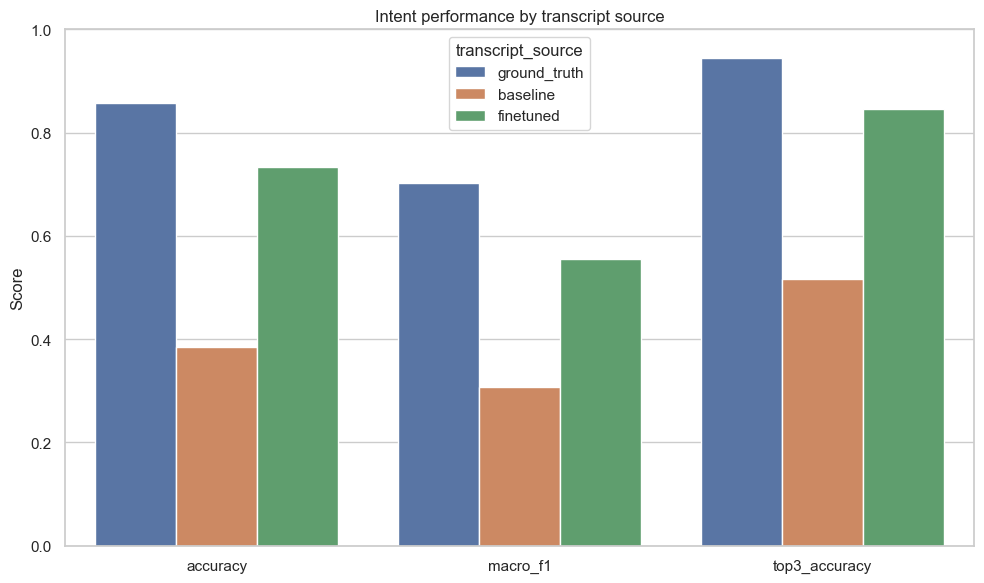

In [21]:
plot_df = metric_comparison_df.melt(
    id_vars="transcript_source",
    value_vars=["accuracy", "macro_f1", "top3_accuracy"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="metric", y="value", hue="transcript_source")
plt.ylim(0, 1.0)
plt.title("Intent performance by transcript source")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "intent_metric_comparison.png", dpi=150)
plt.show()


## Cell 21 — Plot confidence distributions


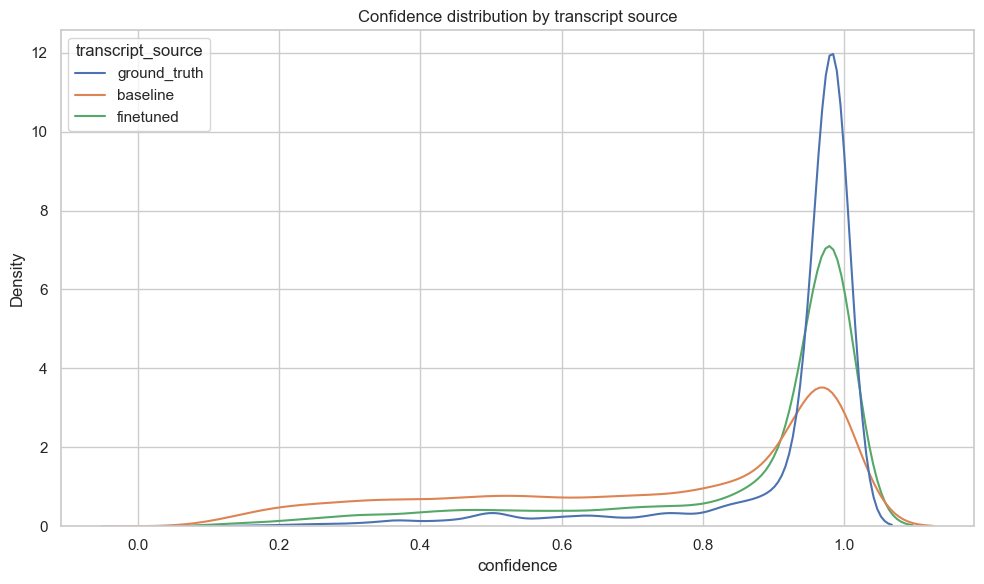

In [22]:
confidence_plot_df = pd.concat([
    ground_truth_df[["confidence"]].assign(transcript_source="ground_truth"),
    baseline_df[["confidence"]].assign(transcript_source="baseline"),
    finetuned_df[["confidence"]].assign(transcript_source="finetuned"),
], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=confidence_plot_df, x="confidence", hue="transcript_source", common_norm=False)
plt.title("Confidence distribution by transcript source")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confidence_distribution_comparison.png", dpi=150)
plt.show()


## Cell 22 — Save all required outputs


In [23]:
ground_truth_df.to_csv(REPORTS_DIR / "intent_predictions_ground_truth.csv", index=False)
baseline_df.to_csv(REPORTS_DIR / "intent_predictions_baseline.csv", index=False)
finetuned_df.to_csv(REPORTS_DIR / "intent_predictions_finetuned.csv", index=False)

metric_comparison_df.to_csv(REPORTS_DIR / "metric_comparison.csv", index=False)
confidence_comparison_df.to_csv(REPORTS_DIR / "confidence_comparison.csv", index=False)
per_intent_f1_comparison_df.to_csv(REPORTS_DIR / "per_intent_f1_comparison.csv", index=False)
per_scenario_f1_comparison_df.to_csv(REPORTS_DIR / "per_scenario_f1_comparison.csv", index=False)

error_propagation_results_df = comparison_df.copy()
error_propagation_results_df.to_csv(REPORTS_DIR / "error_propagation_results.csv", index=False)

np.save(REPORTS_DIR / "ground_truth_intent_probabilities.npy", ground_truth_probs)
np.save(REPORTS_DIR / "baseline_intent_probabilities.npy", baseline_probs)
np.save(REPORTS_DIR / "finetuned_intent_probabilities.npy", finetuned_probs)

print("Saved notebook 08 outputs to reports/")


Saved notebook 08 outputs to reports/


## Cell 23 — Final summary


In [24]:
print("=" * 72)
print("ERROR PROPAGATION ANALYSIS SUMMARY")
print("=" * 72)
for _, row in metric_comparison_df.iterrows():
    print(
        f"{row['transcript_source']:12s} | "
        f"acc={row['accuracy']:.4f} | "
        f"macro_f1={row['macro_f1']:.4f} | "
        f"top3={row['top3_accuracy']:.4f} | "
        f"mean_conf={row['mean_confidence']:.4f}"
    )
print()
print("Recovery from baseline after ASR fine-tuning:")
print(f"  Accuracy recovery : {recovery_acc:.4f}")
print(f"  Macro-F1 recovery : {recovery_f1:.4f}")
print()
print(f"Reports saved to: {REPORTS_DIR}")


ERROR PROPAGATION ANALYSIS SUMMARY
ground_truth | acc=0.8577 | macro_f1=0.7032 | top3=0.9444 | mean_conf=0.9225
baseline     | acc=0.3849 | macro_f1=0.3082 | top3=0.5157 | mean_conf=0.7349
finetuned    | acc=0.7343 | macro_f1=0.5554 | top3=0.8454 | mean_conf=0.8610

Recovery from baseline after ASR fine-tuning:
  Accuracy recovery : 0.3494
  Macro-F1 recovery : 0.2473

Reports saved to: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports
